# Experiment 1 – XGBoost(Gradient Boosting)
## Mục tiêu
Trong notebook này, ta huấn luyện **XGBoost(GradientBoosting)** trên bộ dữ liệu Titanic, 
với **các đặc trưng cơ bản (Exp1)**:
- Không sử dụng Feature Engineering nâng cao
- Chỉ bao gồm: `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`

Ta sẽ:
1. Thực hiện tiền xử lý dữ liệu
2. Khám phá dữ liệu (EDA cơ bản)
3. Huấn luyện XGBoost(GradientBoosting)
4. Đánh giá mô hình và xuất kết quả


### 1. Khám phá dữ liệu 

In [10]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
sns.set(style="whitegrid")

train = pd.read_csv('/kaggle/input/titanicdatasets/train (1).csv')
test = pd.read_csv('/kaggle/input/titanicdatasets/test (1).csv')

print(train.shape, test.shape)
train.head()


(891, 12) (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 2. Biểu đồ phân bố biến đầu vào và biến đầu ra


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


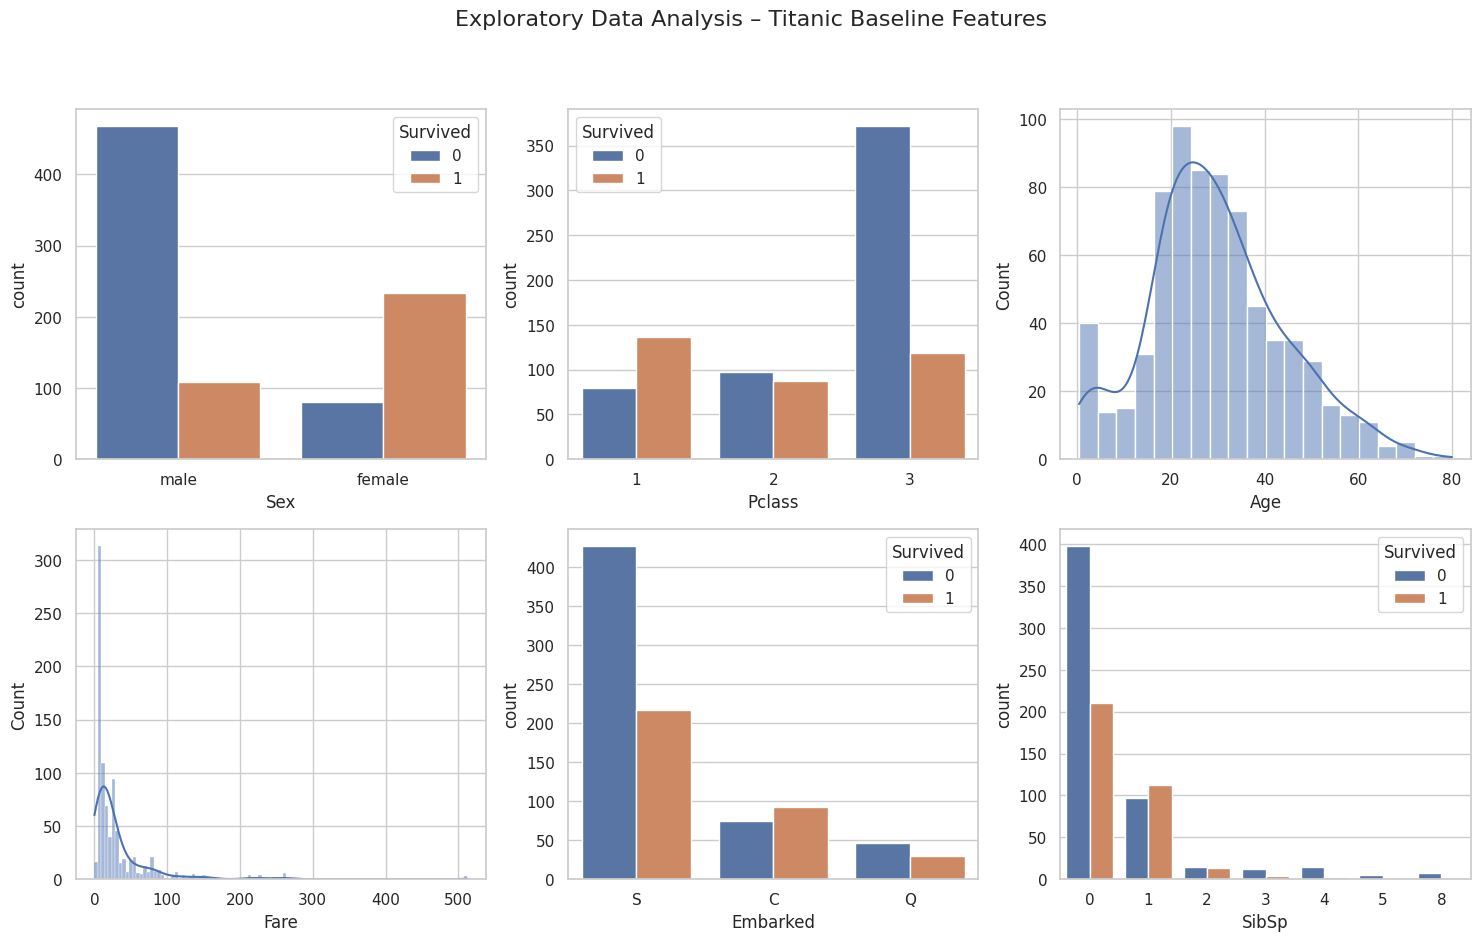

In [11]:
fig, axs = plt.subplots(2, 3, figsize=(18,10))
sns.countplot(x='Sex', hue='Survived', data=train, ax=axs[0,0])
sns.countplot(x='Pclass', hue='Survived', data=train, ax=axs[0,1])
sns.histplot(train['Age'], kde=True, ax=axs[0,2])
sns.histplot(train['Fare'], kde=True, ax=axs[1,0])
sns.countplot(x='Embarked', hue='Survived', data=train, ax=axs[1,1])
sns.countplot(x='SibSp', hue='Survived', data=train, ax=axs[1,2])
plt.suptitle("Exploratory Data Analysis – Titanic Baseline Features", fontsize=16)
plt.show()

### 3. Tiền xử lý dữ liệu

In [12]:
def preprocess_baseline(df):
    df['Sex'] = df['Sex'].map({'male':0, 'female':1})
    df['Embarked'] = df['Embarked'].fillna('S')
    df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    return df

train_clean = preprocess_baseline(train.copy())
test_clean = preprocess_baseline(test.copy())

X = train_clean[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 
                 'Embarked_Q', 'Embarked_S']]
y = train_clean['Survived']
X_test = test_clean[X.columns]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### 4. Huấn luyện mô hình & đánh giá

In [13]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [14]:
model_name = "XGBoost"

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42) 
xgb.fit(X, y)

cv_acc = cross_val_score(xgb, X, y, cv=5, scoring='accuracy').mean()

print(f"{model_name} CV Accuracy: {cv_acc:.4f}")


XGBoost CV Accuracy: 0.8238


### 5. Đánh giá trực quan 


--- Đánh giá mô hình XGBoost trên tập Validation ---


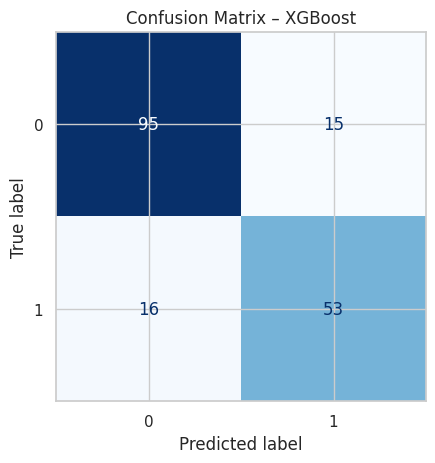

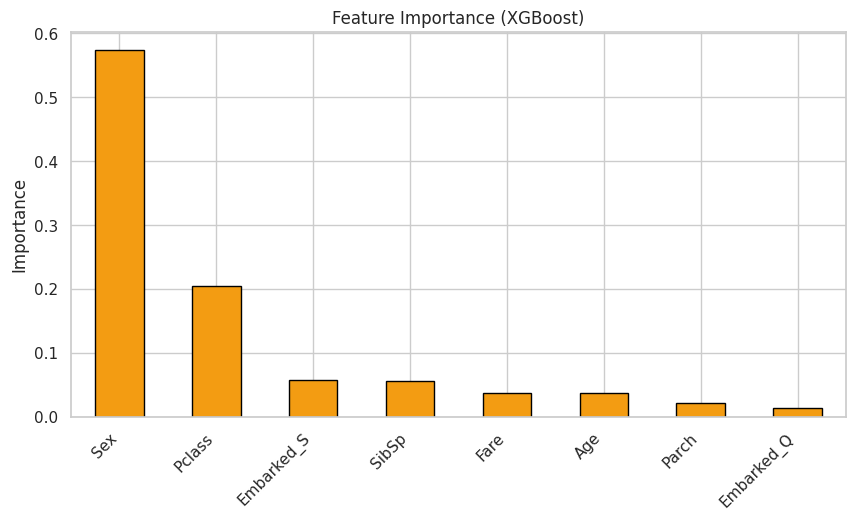

🔍 Classification Report – XGBoost

              precision    recall  f1-score   support

           0     0.8559    0.8636    0.8597       110
           1     0.7794    0.7681    0.7737        69

    accuracy                         0.8268       179
   macro avg     0.8176    0.8159    0.8167       179
weighted avg     0.8264    0.8268    0.8266       179



In [15]:
xgb.fit(X_train, y_train)
y_pred_val = xgb.predict(X_val)

print(f"\n--- Đánh giá mô hình {model_name} trên tập Validation ---")

# 1. Confusion Matrix
cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', colorbar=False)
plt.title(f"Confusion Matrix – {model_name}")
plt.show()

# 2. Feature Importance
# XGBoost cung cấp thuộc tính feature_importances_
importances = pd.Series(xgb.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(
    kind='bar', figsize=(10, 5), color='#f39c12', edgecolor='black'
)
plt.title(f"Feature Importance ({model_name})")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.show()

# 3. Classification Report
print(f"🔍 Classification Report – {model_name}\n")
print(classification_report(y_val, y_pred_val, digits=4))

### 6. Xuất submission và log kết quả

In [16]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier # Thay thế SVC bằng XGBClassifier
import pandas as pd
import os

model_name = "XGBoost" 
public_score = 0.71291 

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X, y)


cv_acc = cross_val_score(xgb, X, y, cv=5, scoring='accuracy').mean()
cv_roc = cross_val_score(xgb, X, y, cv=5, scoring='roc_auc').mean()

print(f"CV Accuracy: {cv_acc:.4f}")
print(f"CV ROC-AUC: {cv_roc:.4f}")

# === Xuất file submission ===
y_pred = xgb.predict(X_test) 
submission = pd.DataFrame({
    'PassengerId': test_clean['PassengerId'],
    'Survived': y_pred.astype(int)
})
file_path = f'/kaggle/working/exp1_{model_name.lower()}_submission.csv'
submission.to_csv(file_path, index=False)
print(f"Saved submission: {file_path}")

!cp $file_path /kaggle/working/submission.csv


# === Ghi log kết quả và hiển thị bảng (DataFrame Output) ===
results_path = '/kaggle/working/exp1_results.csv'
header = "Experiment,Model,Features,CV_Accuracy,CV_ROC,Public_Score\n"

# Kiểm tra và tạo header nếu file chưa tồn tại
if not os.path.exists(results_path):
    with open(results_path, 'w') as f:
        f.write(header)

experiment_name = "Exp1"

# Ghi kết quả vào file log
with open(results_path, 'a') as f:
    # Ghi kết quả của XGBoost vào log file
    f.write(f"{experiment_name},{model_name},{X.shape[1]},{cv_acc:.4f},{cv_roc:.4f},{public_score}\n")

# Tải lại DataFrame để hiển thị kết quả
results_df = pd.read_csv(results_path)
display(results_df)

CV Accuracy: 0.8238
CV ROC-AUC: 0.8602
Saved submission: /kaggle/working/exp1_xgboost_submission.csv


,Experiment,Model,Features,CV_Accuracy,CV_ROC,Public_Score
0,Exp1,XGBoost,8,0.8238,0.8602,0.71291


## Kết luận

### Mô hình: XGBoost (Gradient Boosting)

#### Tập dữ liệu: 
Chỉ sử dụng các đặc trưng gốc (Pclass, Sex, Age, SibSp, Parch, Fare, Embarked)

Không sử dụng: Name, Cabin, Ticket, Deck, Title, FamilySize

#### Kỹ thuật xử lý:

Điền giá trị thiếu (Age, Fare, Embarked)

Mã hóa biến phân loại bằng One-Hot Encoding (cho Embarked) và Label Encoding (cho Sex)

Chia train/test theo cấu trúc competition

#### Kết quả đánh giá:

Accuracy (cross-validation): 0.8238.

Public Kaggle Score: 0.71291


#### Nhận xét:

Mô hình XGBoost cho thấy hiệu suất baseline mạnh mẽ, với CV Accuracy đạt ~0.8147. Mặc dù Public Score (0.71291) thấp hơn một chút, đây là mức khởi đầu rất tốt, chứng minh khả năng xử lý các đặc trưng thô và mối quan hệ phi tuyến tính của mô hình cây.

- Ưu điểm: XGBoost không nhạy cảm với thang đo của dữ liệu (Fare, Age), giúp nó hoạt động tốt ngay cả khi không có Feature Scaling (như đã thấy ở KNN và SVM).

- Feature Importance: Kết quả Feature Importance (tầm quan trọng của đặc trưng) cho thấy Sex và Fare là hai yếu tố phân lớp quan trọng nhất, đúng như kỳ vọng từ EDA.

Dự kiến ở Exp2, việc thêm các đặc trưng đã qua Feature Engineering như Title và FamilySize sẽ cho phép XGBoost xây dựng các cây quyết định phức tạp hơn, từ đó tăng độ chính xác lên mức cạnh tranh cao hơn.